In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].dtype

dtype('float64')

In [9]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [10]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [11]:
df.drop(columns="customerID",inplace=True)

In [12]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [16]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
numeric_feature=x.select_dtypes(exclude="str").columns
one_param=x.select_dtypes(include="str").columns
Onemodel=OneHotEncoder(drop='first')
scaler=StandardScaler()
preprocessor=ColumnTransformer([
    ("onehotencoder",Onemodel,one_param),
    ("standard_scaler",scaler,numeric_feature)
])
x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)

In [17]:
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score
from sklearn.metrics import precision_score,recall_score,f1_score
def evaluate_model(a,b):
    accuracy=accuracy_score(a,b)
    precision=precision_score(a,b)
    recall=recall_score(a,b)
    f1=f1_score(a,b)
    confusion=confusion_matrix(a,b)
    roc_auc=roc_auc_score(a,b)
    return accuracy,precision,recall,f1,confusion,roc_auc

In [18]:
from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [19]:
models={
    "LogisticRegression":LogisticRegression(),
    "RidgeClassifier":RidgeClassifier(),
    "SVC":SVC(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "xgboost":XGBClassifier()
}
for i in range(len(list(models))):
    new_model=list(models.values())[i]
    new_model.fit(x_train,y_train)

    y_train_pred=new_model.predict(x_train)
    y_test_pred=new_model.predict(x_test)

    t_accuracy,t_precision,t_recall,t_f1,t_confusion,t_roc_auc=evaluate_model(y_train,y_train_pred)
    test_accuracy,test_precision,test_recall,test_f1,test_confusion,test_roc_auc=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("Model perform in training data:")
    print("accuracy_score :{:.4f}".format(t_accuracy))
    print("precision_score :{:.4f}".format(t_precision))
    print("recall :{:.4f}".format(t_recall))
    print("fl_score :{:.4f}".format(t_f1))
    print("confusion_matrix :",t_confusion)
    print("roc_auc_score:{:.4f}".format(t_roc_auc))

    
    print('-'*35)
    print("\n")
    print("Model perform on test data")
    print("accuracy_score :{:.4f}".format(test_accuracy))
    print("precision_score :{:.4f}".format(test_precision))
    print("recall :{:.4f}".format(test_recall))
    print("fl_score :{:.4f}".format(test_f1))
    print("confusion_matrix :",test_confusion)
    print("roc_auc_score:{:.4f}".format(test_roc_auc))
   
    print('='*35)
    print('\n')

LogisticRegression
Model perform in training data:
accuracy_score :0.8035
precision_score :0.6583
recall :0.5408
fl_score :0.5938
confusion_matrix : [[3718  420]
 [ 687  809]]
roc_auc_score:0.7196
-----------------------------------


Model perform on test data
accuracy_score :0.8219
precision_score :0.6871
recall :0.6005
fl_score :0.6409
confusion_matrix : [[934 102]
 [149 224]]
roc_auc_score:0.7510


RidgeClassifier
Model perform in training data:
accuracy_score :0.7985
precision_score :0.6576
recall :0.5033
fl_score :0.5702
confusion_matrix : [[3746  392]
 [ 743  753]]
roc_auc_score:0.7043
-----------------------------------


Model perform on test data
accuracy_score :0.8240
precision_score :0.7076
recall :0.5710
fl_score :0.6320
confusion_matrix : [[948  88]
 [160 213]]
roc_auc_score:0.7431


SVC
Model perform in training data:
accuracy_score :0.8136
precision_score :0.7128
recall :0.4993
fl_score :0.5873
confusion_matrix : [[3837  301]
 [ 749  747]]
roc_auc_score:0.7133
---------

In [20]:
RandomForest_param={"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

Svc_param={
    "C": [0.1, 1, 10, 100, 1000],
    "kernel": ['linear', 'poly', 'rbf', 'sigmoid'], 
    "gamma": ['scale', 'auto', 0.001, 0.01, 0.1]
}

xgboost_param={
    "n_estimators":[100, 200, 500, 1000],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "max_depth":[5, 8, 15, None, 10],
    "gamma": [0, 0.1, 0.2, 0.3, 0.4],
    "scale_pos_weight": [1, 2, 3, 4, 5]
}

In [21]:
model_tunning=[
    ("RandomForest",RandomForestClassifier(),RandomForest_param),
    ("SVC",SVC(),Svc_param),
    ("xgboost",XGBClassifier(),xgboost_param)
]

In [22]:
from sklearn.model_selection import RandomizedSearchCV
model_param={}
for name,model,param in model_tunning:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=param,
                                   n_iter=20,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(x_train,y_train)
    model_param[name]=random.best_params_
for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
---------------- Best Params for RandomForest -------------------
{'n_estimators': 500, 'min_samples_split': 15, 'max_features': 5, 'max_depth': None}
---------------- Best Params for SVC -------------------
{'kernel': 'poly', 'gamma': 0.01, 'C': 1000}
---------------- Best Params for xgboost -------------------
{'scale_pos_weight': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3}


In [23]:
models={
    "SVC":SVC(kernel='poly',gamma='scale', C=1),
    "RandomForestClassifier":RandomForestClassifier(n_estimators=500,min_samples_split=20,max_features=5,max_depth=10),
    "xgboost":XGBClassifier(scale_pos_weight=1,n_estimators=100,max_depth=10,learning_rate=0.1,gamma=0.4)
}
for i in range(len(list(models))):
    new_model=list(models.values())[i]
    new_model.fit(x_train,y_train)

    y_train_pred=new_model.predict(x_train)
    y_test_pred=new_model.predict(x_test)

    t_accuracy,t_precision,t_recall,t_f1,t_confusion,t_roc_auc=evaluate_model(y_train,y_train_pred)
    test_accuracy,test_precision,test_recall,test_f1,test_confusion,test_roc_auc=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("Model perform in training data:")
    print("accuracy_score :{:.4f}".format(t_accuracy))
    print("precision_score :{:.4f}".format(t_precision))
    print("recall :{:.4f}".format(t_recall))
    print("fl_score :{:.4f}".format(t_f1))
    print("confusion_matrix :",t_confusion)
    print("roc_auc_score:{:.4f}".format(t_roc_auc))

    
    print('-'*35)
    print("\n")
    print("Model perform on test data")
    print("accuracy_score :{:.4f}".format(test_accuracy))
    print("precision_score :{:.4f}".format(test_precision))
    print("recall :{:.4f}".format(test_recall))
    print("fl_score :{:.4f}".format(test_f1))
    print("confusion_matrix :",test_confusion)
    print("roc_auc_score:{:.4f}".format(test_roc_auc))
   
    print('='*35)
    print('\n')

SVC
Model perform in training data:
accuracy_score :0.8117
precision_score :0.7240
recall :0.4699
fl_score :0.5699
confusion_matrix : [[3870  268]
 [ 793  703]]
roc_auc_score:0.7026
-----------------------------------


Model perform on test data
accuracy_score :0.8105
precision_score :0.6992
recall :0.4987
fl_score :0.5822
confusion_matrix : [[956  80]
 [187 186]]
roc_auc_score:0.7107


RandomForestClassifier
Model perform in training data:
accuracy_score :0.8349
precision_score :0.7550
recall :0.5602
fl_score :0.6431
confusion_matrix : [[3866  272]
 [ 658  838]]
roc_auc_score:0.7472
-----------------------------------


Model perform on test data
accuracy_score :0.8077
precision_score :0.6875
recall :0.5013
fl_score :0.5798
confusion_matrix : [[951  85]
 [186 187]]
roc_auc_score:0.7096


xgboost
Model perform in training data:
accuracy_score :0.9212
precision_score :0.8868
recall :0.8061
fl_score :0.8445
confusion_matrix : [[3984  154]
 [ 290 1206]]
roc_auc_score:0.8845
-------------

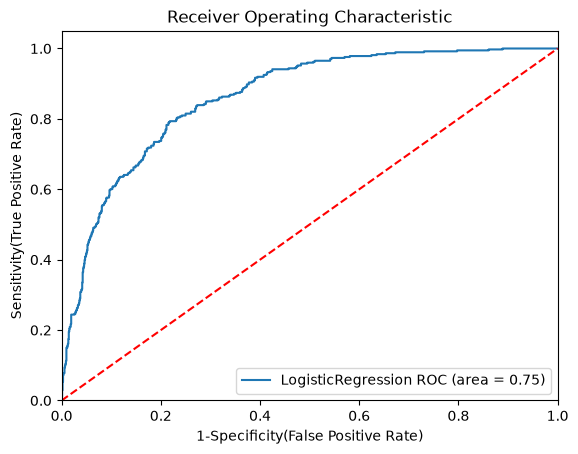

In [24]:
## Plot ROC AUC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': "LogisticRegression",
    'model':LogisticRegression(),
    'auc':  0.7510
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(x_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 

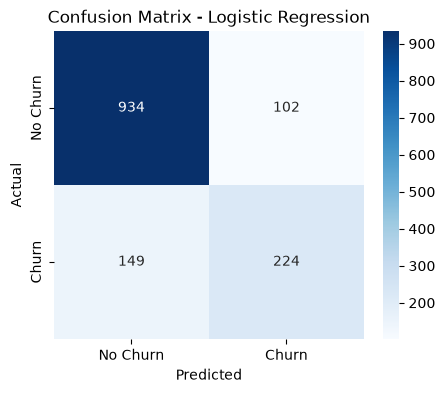

In [25]:

import seaborn as sns

# Example for Logistic Regression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
